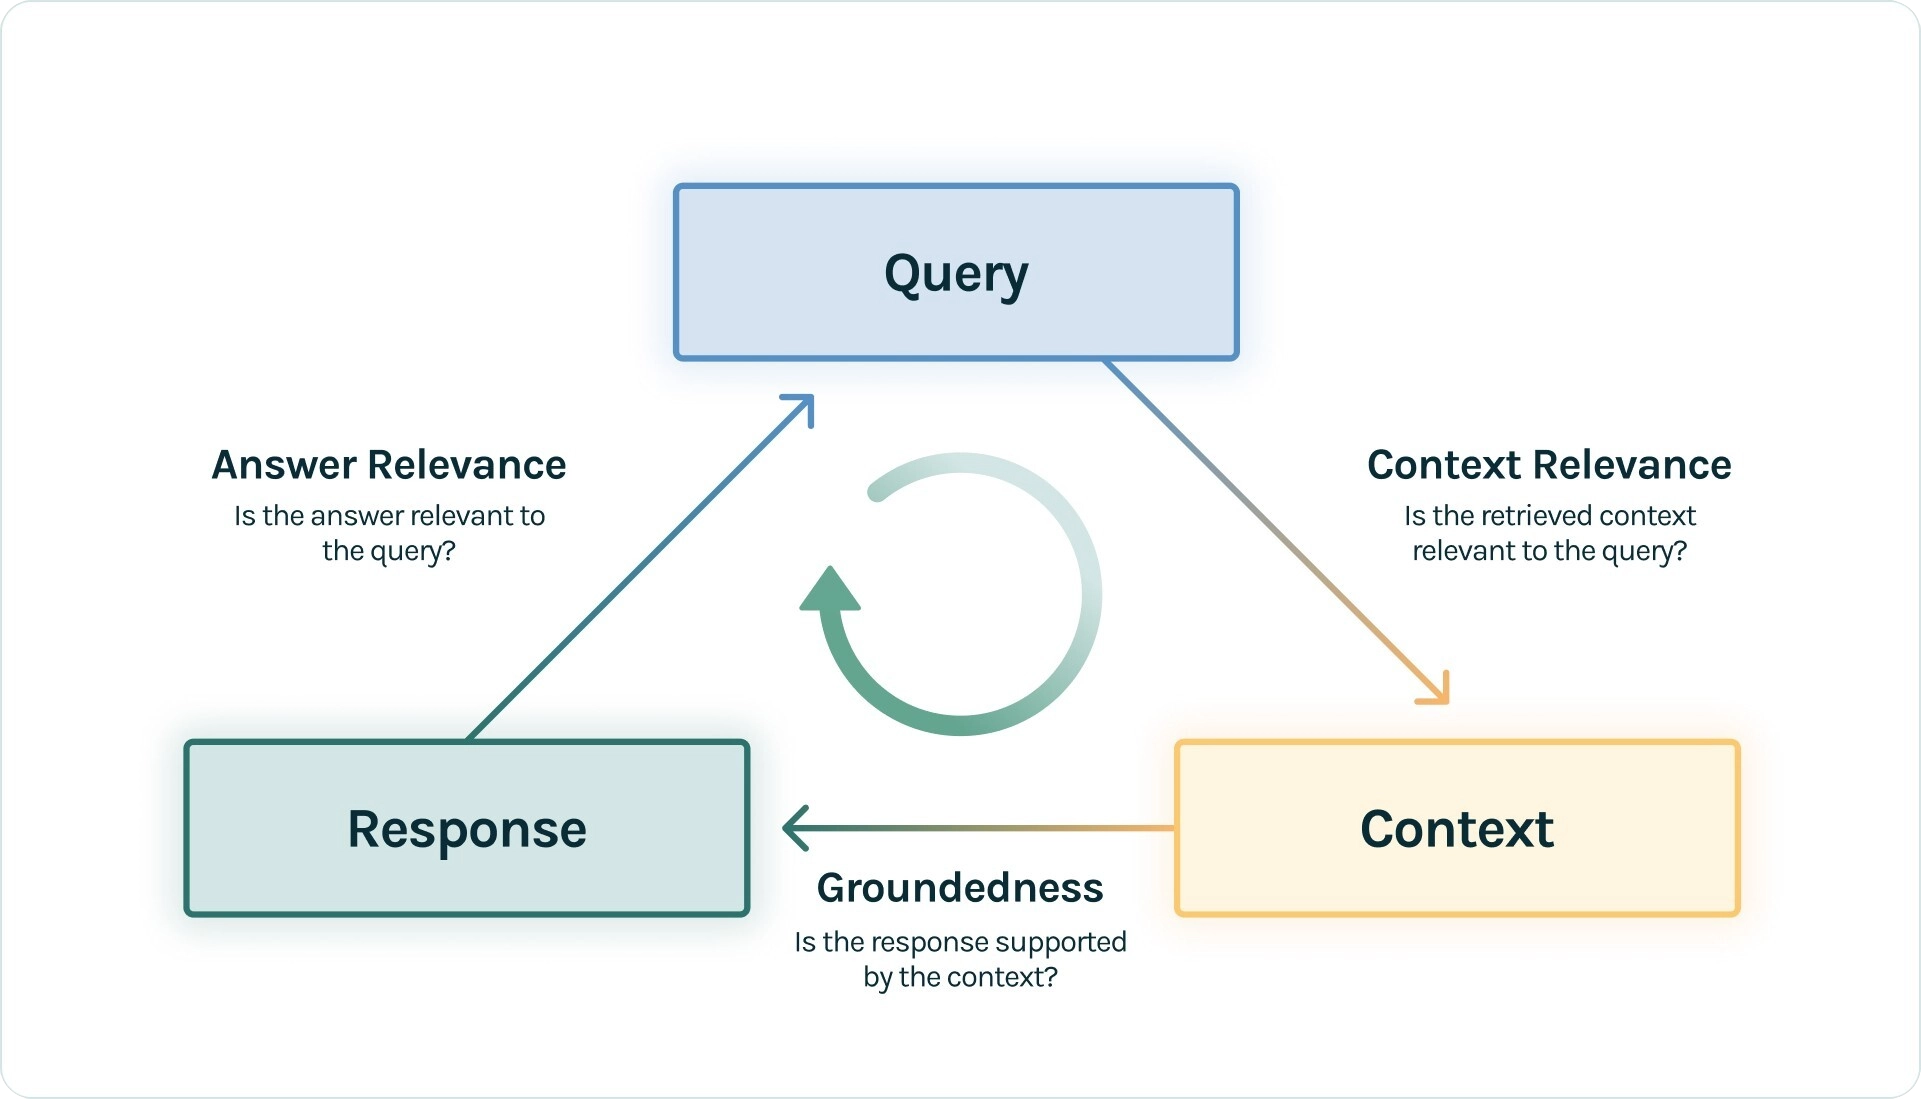

## Objetivos

## 1. Rodar as **20 perguntas** de `benchmark/questions_and_ground_truth.json`.
    a. https://drive.google.com/drive/folders/1YwYq4YnJAd3XGYPnZ2WT1lAgmmqKxb6D?usp=sharing
    b. **colocar arquivo dentro de uma pasta chamada benchmark na raiz do projeto**

## 2. Medir a **RAG Triad**.

## 3. Entregar interface de demonstração e relatório de falhas.

## Composição do benchmark

## -As 20 perguntas estão distribuídas assim - conhecer a distribuição é parte do desafio, porque ela diz onde investir esforço:

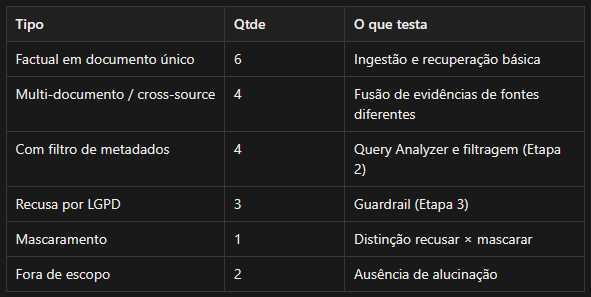

## Pontuação por questão

## Cada questão vale **1,0 ponto**, distribuído:

- **0,5** - a resposta está correta (ou a recusa é correta, nas questões de recusa);
- **0,3** - a citação aponta o arquivo/chunk certo;
- **0,2** - `confidence_level` e `is_refusal` coerentes com a resposta dada.

Responder certo citando a fonte errada vale metade. Recusar uma pergunta legítima vale **zero**, igual a errar.

## RAG Triad

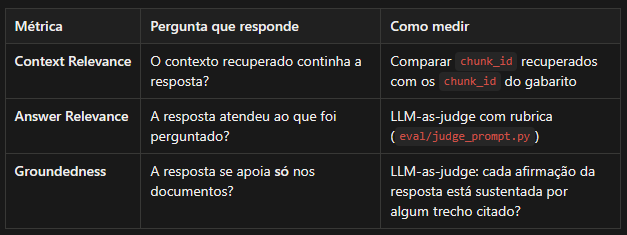

Context Relevance é a métrica diagnóstica: se ela está baixa, o problema é da Etapa 1 ou 2 e não adianta mexer no prompt.

## Critério de pronto

- [ ]  `eval/run_benchmark.py` executa as 20 perguntas e gera `results.json` + tabela resumo.
- [ ]  As três métricas da Triad calculadas e reportadas.
- [ ]  `RELATORIO.md`: taxa de acerto, tabela por tipo de pergunta, **as 3 piores falhas com diagnóstico** (em qual etapa do pipeline a falha se originou) e o que você faria com mais 4 horas.
- [ ]  Interface funcional: CLI, Streamlit ou FastAPI. Simples e que não quebre na demo.

## Instalar as lib da etapa3

In [1]:
!pip install -r /content/requirements_etapa3.txt -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 388.1/388.1 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!pip install faiss-cpu -q

In [3]:
!pip install langchain_community==0.4.2 -q

In [4]:
!pip install rank_bm25 -q

In [5]:
import faiss
import zipfile
from langchain_community.retrievers import BM25Retriever
import pandas as pd
import os
import zipfile
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

/tmp/ipykernel_3935/3451136582.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


In [6]:
FAISS_INDEX_PATH = '/content/faiss_index.zip'
EXTRACTED_FAISS_DIR = '/content/faiss_extracted/'

# Unzip the FAISS index file
with zipfile.ZipFile(FAISS_INDEX_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACTED_FAISS_DIR)

# Assuming the extracted index file is named 'faiss_index.bin'
# You might need to adjust 'faiss_index.bin' if the actual file name is different after extraction
import os
index_file = None
for root, dirs, files in os.walk(EXTRACTED_FAISS_DIR):
    for file in files:
        if file.endswith('.faiss'): # Changed from .bin to .faiss
            index_file = os.path.join(root, file)
            break
    if index_file: # Found the file, break outer loop
        break

if index_file:
    faiss_index = faiss.read_index(index_file)
    print(f"FAISS index loaded successfully from: {index_file}")
else:
    print(f"No FAISS index file (.faiss) found in {EXTRACTED_FAISS_DIR}")

FAISS index loaded successfully from: /content/faiss_extracted/index.faiss


In [7]:
# Display some information about the loaded index (optional)
if 'faiss_index' in locals():
    print(f"Index dimension: {faiss_index.d}")
    print(f"Number of vectors in the index: {faiss_index.ntotal}")

Index dimension: 384
Number of vectors in the index: 5638


In [8]:
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Carrega o FAISS vector store completo, incluindo os embeddings e o docstore
# Use allow_dangerous_deserialization=True se estiver carregando de uma fonte confiável
loaded_vector_store = FAISS.load_local(EXTRACTED_FAISS_DIR, embeddings, allow_dangerous_deserialization=True)

print("FAISS vector store (LangChain object) carregado com sucesso.")

/tmp/ipykernel_3935/3508237927.py:1: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

FAISS vector store (LangChain object) carregado com sucesso.


In [9]:
print('Coletando metadados únicos do índice FAISS para validação...')

# Dicionário para armazenar todas as chaves de metadados e seus valores únicos
all_unique_metadata = {}

# No LangChain FAISS, o docstore contém os documentos indexados.
# Podemos iterar sobre eles para extrair os metadados.
# Para um índice muito grande, você pode querer amostrar os documentos.
# Aqui, tentamos recuperar todos os documentos disponíveis no docstore.

# Certifique-se de que 'loaded_vector_store' está disponível do contexto anterior.
if 'loaded_vector_store' in locals():
    try:
        # Acessar o dicionário interno do docstore para obter todos os documentos e seus metadados
        # A forma correta de acessar os documentos é através de .docstore._dict.values()
        doc_objects = loaded_vector_store.docstore._dict.values()

        for doc in doc_objects:
            for key, value in doc.metadata.items():
                if key not in all_unique_metadata:
                    all_unique_metadata[key] = set()
                all_unique_metadata[key].add(str(value)) # Converte para string para consistência

    except Exception as e:
        print(f"Erro ao acessar docstore para extrair metadados: {e}")
        print("Não foi possível extrair metadados dinamicamente. Por favor, verifique a estrutura do seu índice FAISS ou a forma como ele foi carregado.")
else:
    print("Variável 'loaded_vector_store' não encontrada. Certifique-se de que o índice FAISS foi carregado anteriormente.")

Coletando metadados únicos do índice FAISS para validação...


In [10]:
print('Todos os metadados únicos encontrados nos chunks:')
df_metadados = pd.DataFrame(all_unique_metadata.items(), columns=['Chave', 'Valores Únicos'])
df_metadados

Todos os metadados únicos encontrados nos chunks:


,Chave,Valores Únicos
0,source_file,"{customer_015_duvida_relatorio_dre.txt, custom..."
1,doc_type,"{analytics, customer, ata, pdv, ecommerce, pdf..."
2,chunk_id,"{sales-2340, customers-485, customers-634, sal..."
3,sensitivity,"{interno, restrito, publico}"
4,table_topics,"{['salario', 'email', 'cargo', 'funcionario', ..."
5,customer_id,"{CUST031, CUST1016, CUST045, CUST1152, CUST097..."
6,producer,{ReportLab PDF Library - (opensource)}
7,creator,{(unspecified)}
8,creationdate,{2026-08-24T12:03:14-03:00}
9,author,{(anonymous)}


In [11]:
import re
import unicodedata
import pandas as pd
from typing import List, Dict, Any


def remove_diacritics(text):
    """Remove diacríticos (acentos) de uma string."""
    if not isinstance(text, str):
        return ""
    return ''.join(c for c in unicodedata.normalize('NFD', text) if unicodedata.category(c) != 'Mn')

def query_analyzer(query: str, vector_store) -> Dict[str, List[Any]]:
    """
    Analisa a consulta do usuário, varrendo dinamicamente os metadados dos chunks
    (como table_topics) para mapear o arquivo de origem correto.
    """
    identified_metadata_filters = {}
    normalized_query = remove_diacritics(query).lower()

    print(f"\n[Query Analyzer] Analisando a query: '{query}'")

    # Mapeamento dinâmico de termos em português para arquivos baseados nos table_topics
    topic_to_file_map = {
        'salario': 'employees.csv',
        'email': 'employees.csv',
        'cargo': 'employees.csv',
        'funcionario': 'employees.csv',
        'colaborador': 'employees.csv',
        'pagamento': 'employees.csv',
        'venda': 'sales.csv',
        'faturamento': 'sales.csv',
        'receita': 'sales.csv',
        'pedido': 'sales.csv',
        'cliente': 'customers.csv',
        'consumidor': 'customers.csv',
        'cadastro': 'customers.csv',
        'produto': 'products.json',
        'preco': 'products.json',
        'estoque': 'store.json',
        'loja': 'store.json'
    }

    matched_files = set()
    for topic, filename in topic_to_file_map.items():
        # Permite que 'produto' corresponda a 'produtos' removendo o limite de palavra final
        if re.search(r'\b' + re.escape(topic), normalized_query):
            matched_files.add(filename)

    if matched_files:
        identified_metadata_filters['source_file'] = list(matched_files)
        print(f"  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: {identified_metadata_filters['source_file']}")

    print(f"[Query Analyzer Debug] Filtros finais gerados: {identified_metadata_filters}")
    return identified_metadata_filters

In [12]:
from langchain_community.retrievers import BM25Retriever

# Extrair todos os documentos do docstore para o recuperador BM25...
print("Extraindo documentos do docstore para o recuperador BM25...")

# Certifique-se de que a lista de documentos contém objetos Document do LangChain
all_docs = []
if 'loaded_vector_store' in locals():
    try:
        doc_objects = loaded_vector_store.docstore._dict.values()
        all_docs = [doc for doc in doc_objects if doc is not None] # Filtrar por None, se houver
    except Exception as e:
        print(f"Erro ao extrair documentos do docstore: {e}")
else:
    print("'loaded_vector_store' não encontrado. Certifique-se de que o índice FAISS foi carregado.")

if all_docs:
    print(f"{len(all_docs)} documentos extraídos com sucesso para o recuperador BM25.")
    # Corrigir: Passar k=len(all_docs) durante a inicialização do BM25Retriever
    bm25_retriever = BM25Retriever.from_documents(all_docs, k=len(all_docs))
    print("Recuperador BM25 criado com sucesso com k=%s." % len(all_docs))
else:
    print("Não foi possível criar o recuperador BM25: Nenhuns documentos encontrados.")

Extraindo documentos do docstore para o recuperador BM25...
5638 documentos extraídos com sucesso para o recuperador BM25.
Recuperador BM25 criado com sucesso com k=5638.


In [13]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def apply_filters_to_docs(docs: List[Document], filters: Dict[str, List[str]]) -> List[Document]:
    """Aplica filtros a uma lista de objetos Document.
    Cada chave de filtro é uma condição AND, e os valores dentro de uma chave são condições OR.
    """
    if not filters:
        return docs

    filtered_docs = []
    for doc in docs:
        match_all_keys = True
        for key, filter_values_list in filters.items():
            doc_value = doc.metadata.get(key)

            # Se a chave do filtro não existe no metadado do documento, não há correspondência
            if doc_value is None:
                match_all_keys = False
                break

            # Converta doc_value para string para comparação consistente e trate case-insensitively
            doc_value_str = str(doc_value).lower()

            # Verifica se o doc_value corresponde a algum dos valores de filtro (condição OR)
            key_match = False
            for filter_val in filter_values_list:
                if doc_value_str == str(filter_val).lower():
                    key_match = True
                    break

            # Se não houve correspondência para esta chave, o documento não corresponde a todos os filtros
            if not key_match:
                match_all_keys = False
                break

        if match_all_keys:
            filtered_docs.append(doc)

    return filtered_docs

def reciprocal_rank_fusion(ranked_lists: List[List[Document]], k_rrf: int = 60) -> List[Document]:
    """Implementa o algoritmo Reciprocal Rank Fusion (RRF) para combinar listas ranqueadas de documentos.
    Assume que 'chunk_id' é um identificador único para cada documento.
    """
    fused_scores = {}
    for ranked_list in ranked_lists:
        for rank, doc in enumerate(ranked_list):
            doc_id = doc.metadata.get('chunk_id') # Usando 'chunk_id' como ID único
            if not doc_id:
                # Fallback se 'chunk_id' não estiver presente, ou tratar como erro
                doc_id = hash(doc.page_content) # Cria um hash simples para identificar o documento

            if doc_id not in fused_scores:
                fused_scores[doc_id] = {'score': 0, 'doc': doc}
            fused_scores[doc_id]['score'] += 1 / (k_rrf + rank + 1) # rank é 0-indexed

    # Ordena os documentos pela pontuação fundida
    sorted_docs_with_scores = sorted(fused_scores.values(), key=lambda x: x['score'], reverse=True)
    return [item['doc'] for item in sorted_docs_with_scores]

## Esta função combina os resultados das buscas do FAISS e BM25, enviando para o RRF.

In [14]:
from typing import List, Dict, Any
from langchain_core.documents import Document

def get_filtered_hybrid_docs(query: str, metadata_df: pd.DataFrame,
                             k_results: int = 10, fetch_k_dense: int = 5638, k_bm25_raw: int = 5638) -> List[Document]:
    """Realiza uma busca híbrida com RRF, aplicando filtros identificados pelo query_analyzer.

    Args:
        query (str): A pergunta do usuário.
        metadata_df (pd.DataFrame): DataFrame com metadados únicos para validação de filtros.
        k_results (int): Número final de documentos a serem retornados após a fusão.
        fetch_k_dense (int): Número de documentos a buscar inicialmente no retriever denso antes do filtro.
        k_bm25_raw (int): Número de documentos a buscar inicialmente no retriever BM25 antes do filtro.

    Returns:
        List[Document]: Lista de documentos ranqueados e filtrados.
    """
    print(f"\n--- Realizando Busca Híbrida Filtrada para: '{query}' ---")
    identified_filters = query_analyzer(query, metadata_df)
    print(f"Filtros identificados: {identified_filters}")

    # --- 1. Preparar filtros para o retriever denso (FAISS) ---
    faiss_filter_dict = {}
    for key, values in identified_filters.items():
        if len(values) > 1: # Para múltiplos valores, usa o operador '$in'
            faiss_filter_dict[key] = {"$in": values}
        elif len(values) == 1: # Para um único valor, usa a correspondência exata
            faiss_filter_dict[key] = values[0]
    print(f"  FAISS filter dict para search_kwargs: {faiss_filter_dict}")

    # --- 2. Busca e Filtragem com Retriever Denso (FAISS) ---
    print("\nExecutando busca densa (FAISS) com filtros...")

    # Para depuração: tentar busca FAISS sem filtro para ver se há documentos relevantes
    print("  Tentando busca FAISS sem filtro para debug...")
    dense_retriever_no_filter = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense,
        }
    )
    dense_docs_no_filter = dense_retriever_no_filter.invoke(query)
    print(f"  -> {len(dense_docs_no_filter)} documentos densos encontrados sem filtro.")
    # Adicionar depuração detalhada para dense_docs_no_filter
    found_employees_in_dense_no_filter = [doc for doc in dense_docs_no_filter if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_dense_no_filter:
        print(f"    -> ENCONTRADO: {len(found_employees_in_dense_no_filter)} documentos 'employees.csv' na busca densa SEM filtro. Conteúdo do primeiro: {found_employees_in_dense_no_filter[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.")

    # Re-instancia o retriever denso para aplicar os search_kwargs com filtro
    dense_retriever_filtered_instance = loaded_vector_store.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": k_results,
            "fetch_k": fetch_k_dense, # Busca mais candidatos antes de aplicar o filtro FAISS
            "filter": faiss_filter_dict
        }
    )
    dense_docs_filtered = dense_retriever_filtered_instance.invoke(query)
    print(f"-> {len(dense_docs_filtered)} documentos densos filtrados encontrados.")

    # --- 3. Busca e Filtragem com Retriever Esparso (BM25) ---
    print("\nExecutando busca esparsa (BM25) e aplicando filtros pós-recuperação...")
    # O bm25_retriever global já foi criado com todos os documentos.
    # Busca mais documentos para garantir que haja suficientes após a filtragem manual.
    bm25_raw_docs = bm25_retriever.invoke(query, k=k_bm25_raw)
    # Adicionar depuração aqui para bm25_raw_docs antes de filtrar
    print(f"  -> {len(bm25_raw_docs)} documentos BM25 brutos encontrados.")
    # Adicionar depuração detalhada para bm25_raw_docs
    found_employees_in_bm25_raw = [doc for doc in bm25_raw_docs if doc.metadata.get('source_file') == 'employees.csv']
    if found_employees_in_bm25_raw:
        print(f"    -> ENCONTRADO: {len(found_employees_in_bm25_raw)} documentos 'employees.csv' na busca BM25 SEM filtro. Conteúdo do primeiro: {found_employees_in_bm25_raw[0].page_content[:100]}...")
    else:
        print("    -> NENHUM documento 'employees.csv' encontrado na busca BM25 SEM filtro.")

    bm25_docs_filtered = apply_filters_to_docs(bm25_raw_docs, identified_filters)
    # Limita ao k_results esperado para RRF se houver mais documentos do que o desejado
    bm25_docs_filtered = bm25_docs_filtered[:k_results]
    print(f"-> {len(bm25_docs_filtered)} documentos BM25 filtrados encontrados.")

    # --- 4. Reciprocal Rank Fusion (RRF) ---
    print("\nCombinando resultados de FAISS e BM25 com RRF...")
    hybrid_docs_final = reciprocal_rank_fusion([dense_docs_filtered, bm25_docs_filtered], k_rrf=60)

    print(f"-> {len(hybrid_docs_final)} documentos híbridos ranqueados com RRF.")
    return hybrid_docs_final

## Implementação das restrições de query enviadas
## - out-of-scope
## - lgpd
## - informação restrita

## Pydantic

In [15]:
from typing import Literal, Optional
from pydantic import BaseModel, Field, model_validator


class SourceEvidence(BaseModel):
    filepath: str = Field(
        ...,
        description="Arquivo de origem do trecho citado"
    )
    chunk_id: str = Field(
        ...,
        description="Identificador do chunk recuperado"
    )
    quotation: str = Field(
        ...,
        max_length=500,
        description="Trecho literal que sustenta a resposta"
    )


class RAGResponse(BaseModel):
    answer: Optional[str] = None

    confidence_level: Literal[
        "alta",
        "media",
        "baixa",
        "recusado"
    ]

    sources_used: list[SourceEvidence]

    reasoning: str

    is_refusal: bool

    refusal_reason: Literal[
        "lgpd",
        "fora_de_escopo",
        "sem_evidencia",
        "erro_interno_llm",
        None
    ] = None

    @model_validator(mode="after")
    def validate_consistency(self):

        if self.is_refusal:
            if self.sources_used:
                raise ValueError(
                    "Resposta recusada não pode conter sources_used."
                )

            if self.confidence_level != "recusado":
                raise ValueError(
                    "Resposta recusada deve ter confidence_level='recusado'."
                )

            if self.refusal_reason is None:
                raise ValueError(
                    "Resposta recusada deve possuir refusal_reason."
                )

            # NEW LOGIC: Set default answer if it's None in a refusal case
            if self.answer is None:
                if self.refusal_reason == "lgpd":
                    self.answer = "Não posso fornecer essa informação por restrições de privacidade."
                elif self.refusal_reason == "fora_de_escopo":
                    self.answer = "A pergunta está fora do escopo da base VendeFácil."
                elif self.refusal_reason == "sem_evidencia":
                    self.answer = "Não encontrei evidências suficientes para responder."
                elif self.refusal_reason == "erro_interno_llm":
                    self.answer = "Ocorreu um erro interno ao tentar gerar a resposta."
                else: # Fallback for any other refusal reason
                    self.answer = "A solicitação foi recusada."

        else:
            if not self.sources_used:
                raise ValueError(
                    "Resposta não recusada precisa conter evidências."
                )

            if self.confidence_level == "recusado":
                raise ValueError(
                    "Resposta aceita não pode ter confidence_level='recusado'."
                )

            if self.refusal_reason is not None:
                raise ValueError(
                    "Resposta aceita não deve possuir refusal_reason."
                )

            # Ensure answer is not None if it's not a refusal
            if self.answer is None:
                raise ValueError(
                    "Resposta não recusada deve ter um campo 'answer' preenchido."
                )

        return self

## Guardrail

In [16]:
import re
from typing import Literal


LGPDAction = Literal["recusar", "mascarar", "responder"]


SENSITIVE_DENY_TERMS = [
    "salário",
    "salario",
    "remuneração",
    "remuneracao",
    "cpf",
    "senha",
    "token",
    "chave api",
    "api key",
    "chave pix",
    "dados bancários",
    "dados bancarios",
    "conta bancária",
    "conta bancaria",
    "diagnóstico",
    "diagnostico",
    "doença",
    "doenca",
]

MASK_TERMS = [
    "email",
    "e-mail",
    "telefone",
    "celular",
    "endereço",
    "endereco",
    "cartão",
    "cartao",
]


def classify_lgpd_query(query: str) -> LGPDAction:
    q = query.lower()

    # 1. Bloqueio direto de dados altamente sensíveis
    if any(term in q for term in SENSITIVE_DENY_TERMS):

        # Exceção: pergunta claramente agregada
        aggregate_terms = [
            "média",
            "media",
            "total",
            "quantos",
            "percentual",
            "distribuição",
            "distribuicao",
            "estatística",
            "estatistica",
        ]

        if any(term in q for term in aggregate_terms):
            return "responder"

        return "recusar"

    # 2. Informação que pode ser devolvida com mascaramento
    if any(term in q for term in MASK_TERMS):
        return "mascarar"

    # 3. Demais consultas
    return "responder"

In [17]:
MIN_GROUP_SIZE = 3

In [18]:
def build_refusal(reason: str, message: str) -> RAGResponse:
    return RAGResponse(
        answer=message,
        confidence_level="recusado",
        sources_used=[],
        reasoning="Consulta bloqueada por política de segurança.",
        is_refusal=True,
        refusal_reason=reason,
    )

In [19]:
def apply_input_guardrail(query: str):

    action = classify_lgpd_query(query)

    if action == "recusar":
        return build_refusal(
            reason="lgpd",
            message=(
                "Não posso fornecer essa informação porque ela "
                "envolve dados pessoais ou confidenciais."
            )
        )

    return None

In [20]:
VENDEFACIL_TERMS = [
    # Empresa / operação
    "vendefácil", "vendefacil",
    "cliente", "pedido", "pdv",
    "estoque", "produto", "suporte",
    "venda", "loja", "tef", "frete",
    "relatório", "relatorio",

    # Funcionários / RH
    "funcionário", "funcionario",
    "colaborador", "equipe",
    "rh", "recursos humanos",
    "benefício", "beneficio",
    "benefícios", "beneficios",
    "reembolso de viagens", "reembolso de viagem",
    "auxilio academia", "auxilio academia",
    "auxílio academia", "auxilio academia",

    # Benefícios corporativos
    "caju",
    "cartão caju", "cartao caju",
    "cartão", "cartao",
    "vale alimentação", "vale alimentacao",
    "vale refeição", "vale refeicao",

    # Segurança
    "lgpd"
]


def is_out_of_scope(query: str) -> bool:
    q = query.lower()

    return not any(
        term in q
        for term in VENDEFACIL_TERMS
    )

In [21]:
def build_context(docs):
    blocos = []

    for doc in docs:
        blocos.append(
            f"""
FILEPATH: {doc.metadata.get('source_file')}
CHUNK_ID: {doc.metadata.get('chunk_id')}
CONTENT:
{doc.page_content}
"""
        )

    return "\n\n---\n\n".join(blocos)

In [22]:
SYSTEM_PROMPT = """
Responda somente com base no contexto fornecido.

REGRAS IMPORTANTES SOBRE EVIDÊNCIAS:

- filepath e chunk_id devem ser copiados exatamente do contexto.
- quotation deve ser COPIADA E COLADA literalmente do conteúdo do chunk.
- Não resuma.
- Não reescreva.
- Não corrija.
- Não mude palavras.
- Não altere números.
- Não combine trechos diferentes.
- Use uma única sequência contínua de texto existente no chunk.

Antes de retornar o JSON, confirme internamente que cada quotation
aparece literalmente no chunk informado.

Se não conseguir encontrar uma citação literal que sustente a resposta,
recuse com:
is_refusal = true
confidence_level = "recusado"
refusal_reason = "sem_evidencia"
sources_used = []
"""

In [23]:
SYSTEM_PROMPT = """
Responda somente com base no contexto fornecido.

Retorne SEMPRE um objeto JSON com exatamente estes campos:

{
  "answer": "...",
  "confidence_level": "alta|media|baixa|recusado",
  "sources_used": [
    {
      "filepath": "...",
      "chunk_id": "...",
      "quotation": "..."
    }
  ],
  "reasoning": "...",
  "is_refusal": false,
  "refusal_reason": null
}

REGRAS:

- Nunca omita nenhum campo.
- reasoning é obrigatório.
- filepath e chunk_id devem ser copiados exatamente do contexto.
- quotation deve ser copiada literalmente do chunk.
- quotation deve ter no máximo 500 caracteres.
- Use apenas o menor trecho necessário para sustentar a resposta.
- Não copie o chunk inteiro.
- Não copie objetos JSON completos.
- Não resuma nem parafraseie quotation.
- Não combine trechos diferentes.

Se não houver evidência suficiente:

{
  "answer": "Não encontrei evidências suficientes para responder.",
  "confidence_level": "recusado",
  "sources_used": [],
  "reasoning": "Não há evidência suficiente no contexto recuperado.",
  "is_refusal": true,
  "refusal_reason": "sem_evidencia"
}

Retorne somente JSON.
"""

In [24]:
import re

def normalize_text(text: str) -> str:
    """Normaliza texto para comparação: minúsculas, remove pontuação e normaliza espaços."""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text) # Remove pontuação
    text = re.sub(r'\s+', ' ', text).strip() # Normaliza espaços em branco
    return text

def validate_evidence(response: RAGResponse, docs):

    doc_map = {
        (
            doc.metadata.get("source_file"),
            doc.metadata.get("chunk_id")
        ): doc.page_content
        for doc in docs
    }

    for source in response.sources_used:

        key = (source.filepath, source.chunk_id)

        if key not in doc_map:
            raise ValueError(
                f"Fonte inexistente: {key}"
            )

        content = doc_map[key]

        # Normaliza tanto a citação quanto o conteúdo antes de verificar a inclusão
        normalized_quotation = normalize_text(source.quotation)
        normalized_content = normalize_text(content)

        if normalized_quotation not in normalized_content:
            raise ValueError(
                f"Trecho não encontrado no chunk {source.chunk_id} após normalização."
            )

    return True

In [25]:
from pydantic import ValidationError
import json


def generate_validated_response(
    client,
    prompt,
    docs,
    max_retries=2
):
    last_error = None
    current_prompt = prompt

    for attempt in range(max_retries + 1):

        raw_response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {
                    "role": "system",
                    "content": """
Você é um assistente corporativo da VendeFácil.

Sua resposta DEVE conter TODOS os campos:

- answer
- confidence_level
- sources_used
- reasoning
- is_refusal
- refusal_reason

Nunca omita nenhum campo.

Se is_refusal=false:
- sources_used deve conter pelo menos uma fonte.
- refusal_reason deve ser null.

Se is_refusal=true:
- confidence_level deve ser "recusado".
- sources_used deve ser [].
- refusal_reason deve ser:
  "lgpd", "fora_de_escopo" ou "sem_evidencia".
- answer deve ser uma mensagem de recusa apropriada, por exemplo:
  "Não posso fornecer essa informação por restrições de privacidade." (para 'lgpd')
  "A pergunta está fora do escopo da base VendeFácil." (para 'fora_de_escopo')
  "Não encontrei evidências suficientes para responder." (para 'sem_evidencia')
"""
                },
                {
                    "role": "user",
                    "content": current_prompt
                }
            ],
            temperature=0,
            response_format={"type": "json_object"}
        )

        raw_text = raw_response.choices[0].message.content

        try:
            raw_text = raw_text.strip()

            if raw_text.startswith("```"):
                raw_text = raw_text.removeprefix("```json")
                raw_text = raw_text.removeprefix("```")
                raw_text = raw_text.removesuffix("```")
                raw_text = raw_text.strip()
            response = RAGResponse.model_validate_json(
                raw_text
            )

            if not response.is_refusal:
                validate_evidence(
                    response,
                    docs
                )

            return response

        except (ValidationError, ValueError) as e:

            last_error = e

            print(
                f"Tentativa {attempt + 1} inválida:",
                e
            )

            current_prompt = f"""
{prompt}

A resposta anterior foi inválida.

ERRO:
{e}

IMPORTANTE:

O JSON deve conter obrigatoriamente TODOS estes campos:

{{
    "answer": "...",
    "confidence_level": "alta",
    "sources_used": [
        {{
            "filepath": "...",
            "chunk_id": "...",
            "quotation": "..."
        }}
    ],
    "reasoning": "...",
    "is_refusal": false,
    "refusal_reason": null
}}

Não omita nenhum campo.

quotation deve ser copiado LITERALMENTE do contexto.

Retorne apenas JSON.
"""

    raise RuntimeError(
        f"Falha após {max_retries + 1} tentativas. "
        f"Último erro: {last_error}"
    )

In [26]:
from google.colab import userdata
GROQ_API_KEY= userdata.get('GROQ_API_KEY')
#
from google.colab import userdata
OPENROUTER_API_KEY= userdata.get('OPENROUTER_API_KEY')
#
from google.colab import userdata
import os

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

assert os.environ["GROQ_API_KEY"], "GROQ_API_KEY não encontrada."

print("Chave Groq carregada com sucesso.")

#
from openai import OpenAI

client = OpenAI(
    api_key=os.environ["GROQ_API_KEY"],
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "openai/gpt-oss-120b"

Chave Groq carregada com sucesso.


In [27]:
from openai import OpenAI # Usar a biblioteca OpenAI já instalada

# Carregar a chave da API do OpenRouter dos segredos do Colab
os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")

assert os.environ["OPENROUTER_API_KEY"], "OPENROUTER_API_KEY não encontrada."

print("Chave OpenRouter carregada com sucesso.")

# Instanciar o cliente OpenRouter, apontando para o base_url correto
openrouter_client = OpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

FALLBACK_MODEL_NAME = "openai/gpt-oss-20b:free"
FALLBACK_MODEL_NAME = "minimax/minimax-m3:free"
FALLBACK_MODEL_NAME = "liquid/lfm2.5-2.6b:free"
FALLBACK_MODEL_NAME = "inclusionai/ling-3.0-flash-sante:free" # Usando um modelo reconhecido e sua versão mais recente
print(f"Modelo de fallback configurado para: {FALLBACK_MODEL_NAME}")

#
print('Testando conexão com OpenRouter...')

response_openrouter = openrouter_client.chat.completions.create(
    model=FALLBACK_MODEL_NAME, # Usando o modelo de fallback definido
    messages=[
        {
            "role": "user",
            "content": "Responda apenas: conexão OpenRouter OK"
        }
    ],
    temperature=0
)

print(response_openrouter.choices[0].message.content)

Chave OpenRouter carregada com sucesso.
Modelo de fallback configurado para: inclusionai/ling-3.0-flash-sante:free
Testando conexão com OpenRouter...
conexão OpenRouter OK


In [28]:
from pydantic import ValidationError
import json
from openai import RateLimitError


def generate_validated_response(
    llm_client, # Renomeado de 'client' para 'llm_client' para evitar conflito
    prompt,
    docs,
    max_retries=2,
    model_name=MODEL_NAME # Adiciona model_name como argumento com default
):
    last_error = None
    current_prompt = prompt

    for attempt in range(max_retries + 1):

        try:
            raw_response = llm_client.chat.completions.create(
                model=model_name, # Usa o model_name passado como argumento
                messages=[
                    {
                        "role": "system",
                        "content": SYSTEM_PROMPT # Usar o SYSTEM_PROMPT original, que já é robusto
                    },
                    {
                        "role": "user",
                        "content": current_prompt
                    }
                ],
                temperature=0,
                response_format={"type": "json_object"}
            )

            # --- ADDED ROBUSTNESS HERE ---
            # Verifica se raw_response ou raw_response.choices é None ou vazio.
            if not raw_response or not raw_response.choices:
                raise ValueError("LLM retornou uma resposta vazia ou malformada (sem choices).")

            raw_text = raw_response.choices[0].message.content

            raw_text = raw_text.strip()

            if raw_text.startswith("```json"):
                raw_text = raw_text[len("```json"):]

            elif raw_text.startswith("```"):
                raw_text = raw_text[3:]

            if raw_text.endswith("```"):
                raw_text = raw_text[:-3]

            raw_text = raw_text.strip()

            # Verifica se o conteúdo da mensagem é vazio
            if not raw_text:
                raise ValueError("LLM retornou um conteúdo de mensagem vazio.")
            # --- END ADDED ROBUSTNESS ---

            response = RAGResponse.model_validate_json(
                raw_text
            )

            if not response.is_refusal:
                validate_evidence(
                    response,
                    docs
                )

            return response

        except (ValidationError, ValueError, RateLimitError) as e:
            last_error = e

            if isinstance(e, RateLimitError):
                print(f"RateLimitError detectado na tentativa {attempt + 1}. Não haverá mais retentativas internas na generate_validated_response. Este erro será propagado para a rag_pipeline para fallback.")
                raise e # Propaga o RateLimitError imediatamente para rag_pipeline

            # Para outros ValueErrors (como os novos que adicionamos) ou ValidationErrors
            print(
                f"Tentativa {attempt + 1} inválida:",
                e
            )

            current_prompt = f"""
{prompt}

A resposta anterior foi rejeitada pelo validador.

ERRO:
{e}

ATENÇÃO:

A quotation anterior NÃO foi localizada literalmente no chunk.

Para corrigir:

1. Localize no CONTEXTO o chunk informado.
2. Copie uma sequência CONTÍNUA de palavras desse chunk.
3. Cole exatamente essa sequência em "quotation".
4. Não parafraseie.
5. Não resuma.
6. Não acrescente palavras.
7. Não retire palavras no meio da citação.

Se não houver um trecho literal que sustente a resposta,
retorne uma recusa por "sem_evidencia".

Retorne somente JSON.
"""

    raise RuntimeError(
        f"Falha após {max_retries + 1} tentativas. "
        f"Último erro: {last_error}"
    )


In [29]:
def build_prompt(query: str, context: str) -> str:
    return f"""
Você é um assistente corporativo da VendeFácil.

Responda SOMENTE com base no contexto fornecido.

REGRAS:
1. Não use conhecimento externo ao contexto.
2. Toda afirmação factual deve ser sustentada por evidência presente no contexto.
3. Para cada fonte utilizada, informe:
   - filepath
   - chunk_id
   - quotation
4. quotation deve ser um trecho literal copiado do contexto.
  - quotation deve conter somente o menor trecho literal necessário para sustentar a afirmação.
  - quotation deve ter no máximo 500 caracteres.
  - Não copie o chunk inteiro.
  - Não copie objetos JSON completos.
  - Não inclua campos irrelevantes.
- O texto deve ser uma sequência contínua existente no chunk.
5. Nunca invente filepath, chunk_id ou quotation.
6. Se não houver evidência suficiente no CONTEXTO para responder à PERGUNTA:
   - is_refusal = true
   - confidence_level = "recusado"
   - refusal_reason = "sem_evidencia"
   - sources_used = []
   - answer = "Não encontrei evidências suficientes para responder."
7. Se houver evidência suficiente:
   - is_refusal = false
   - refusal_reason = null
   - sources_used deve conter pelo menos uma evidência.
8. confidence_level deve ser somente:
   "alta", "media", "baixa" ou "recusado".

PERGUNTA:
{query}

CONTEXTO:
{context}

Retorne a resposta no formato JSON esperado pelo schema RAGResponse.
"""

In [30]:
import re


def mask_sensitive_data(text: str) -> str:
    """
    Mascara dados pessoais que podem aparecer na resposta
    sem bloquear completamente a consulta.

    Exemplos:
    - e-mail
    - telefone
    - CPF
    - cartão
    """

    if not text:
        return text

    # -----------------------------
    # E-mail
    # silvio@email.com
    # -> s***@email.com
    # -----------------------------
    email_pattern = r'\b([A-Za-z0-9._%+-])([A-Za-z0-9._%+-]*)@([A-Za-z0-9.-]+\.[A-Za-z]{2,})\b'

    text = re.sub(
        email_pattern,
        lambda m: f"{m.group(1)}***@{m.group(3)}",
        text
    )

    # -----------------------------
    # CPF
    # 123.456.789-00
    # -> ***.***.***-**
    # -----------------------------
    cpf_pattern = r'\b\d{3}\.?\d{3}\.?\d{3}-?\d{2}\b'

    text = re.sub(
        cpf_pattern,
        "***.***.***-**",
        text
    )

    # -----------------------------
    # Telefone brasileiro
    # (11) 98765-4321
    # -> (**) *****-4321
    # -----------------------------
    telefone_pattern = r'\(?\d{2}\)?\s*9?\d{4}[-\s]?\d{4}'

    def mask_phone(match):
        digits = re.sub(r'\D', '', match.group())
        return f"(**) *****-{digits[-4:]}"

    text = re.sub(
        telefone_pattern,
        mask_phone,
        text
    )

    # -----------------------------
    # Cartão de crédito
    # 1234 5678 9012 3456
    # -> **** **** **** 3456
    # -----------------------------
    card_pattern = r'\b(?:\d{4}[- ]?){3}\d{4}\b'

    def mask_card(match):
        digits = re.sub(r'\D', '', match.group())
        return f"**** **** **** {digits[-4:]}"

    text = re.sub(
        card_pattern,
        mask_card,
        text
    )

    return text

In [31]:
teste = """
Contato do funcionário:
Email: carlos.mendes@vendefacil.com.br
Telefone: (11) 98765-4321
CPF: 123.456.789-00
Cartão: 1234 5678 9012 3456
"""

print(mask_sensitive_data(teste))


Contato do funcionário:
Email: c***@vendefacil.com.br
Telefone: (**) *****-4321
CPF: ***.***.***-**
Cartão: 12(**) *****-9012 3456



In [34]:
from openai import RateLimitError

def rag_pipeline(query, df_metadados, llm):

    # --------------------------------
    # 1. Fora de escopo
    # --------------------------------
    print("Checar se out-of-scope")
    if is_out_of_scope(query):
        return build_refusal(
            "fora_de_escopo",
            "A pergunta está fora do escopo da base VendeFácil."
        )

    # --------------------------------
    # 2. LGPD de entrada
    # --------------------------------
    print("Checar LGPD")
    lgpd_action = classify_lgpd_query(query)

    if lgpd_action == "recusar":
        return build_refusal(
            "lgpd",
            "Não posso fornecer essa informação por restrições de privacidade."
        )

    # --------------------------------
    # 3. Retrieval
    # --------------------------------
    print("Executando busca híbrida: FAISS + BM25 -> RRF")
    docs = get_filtered_hybrid_docs(
        query,
        df_metadados,
        k_results=5
    )

    if not docs:
        return build_refusal(
            "sem_evidencia",
            "Não encontrei evidências suficientes para responder."
        )

    # --------------------------------
    # 4. Contexto
    # --------------------------------
    context = build_context(docs)

    prompt = build_prompt(
        query=query,
        context=context
    )

    # --------------------------------
    # 5. LLM + Pydantic com Fallback para OpenRouter
    # --------------------------------
    try:
        response = generate_validated_response(
            llm, # Primary LLM client (Groq)
            prompt,
            docs
        )
    except RateLimitError as e:
        print(f"RateLimitError com LLM primário (Groq): {e}.\nTentando fallback com OpenRouter...")
        try:
            response = generate_validated_response(
                openrouter_client, # Fallback LLM client
                prompt,
                docs,
                model_name=FALLBACK_MODEL_NAME # Garantindo que o modelo de fallback é passado
            )
        except Exception as fallback_e:
            print(
        "OpenRouter respondeu, mas não foi possível obter "
        f"uma resposta validada após as tentativas: {fallback_e}"
    )
            return RAGResponse(
                answer="Ocorreu um erro interno ao tentar gerar a resposta com o LLM primário e o fallback.",
                confidence_level="recusado",
                sources_used=[],
                reasoning=f"Falha no LLM primário ({e}) e no fallback ({fallback_e}).",
                is_refusal=True,
                refusal_reason="erro_interno_llm" # Usando o refusal_reason corrigido
            )
    except Exception as e:
        # Outros erros que não sejam RateLimitError
        print(f"Erro inesperado na chamada do LLM: {e}")
        return RAGResponse(
            answer="Erro inesperado ao gerar resposta com LLM.",
            confidence_level="recusado",
            sources_used=[],
            reasoning=f"Falha inesperada no LLM: {e}",
            is_refusal=True,
            refusal_reason="erro_interno_llm" # Usando o refusal_reason corrigido
        )

    # --------------------------------
    # 6. Mascaramento
    # --------------------------------
    if lgpd_action == "mascarar":
        response.answer = mask_sensitive_data(
            response.answer
        )

    return response

In [35]:
rag_pipeline("Qual o salário do funcionário Carlos Mendes?", df_metadados, client)

Checar se out-of-scope
Checar LGPD


RAGResponse(answer='Não posso fornecer essa informação por restrições de privacidade.', confidence_level='recusado', sources_used=[], reasoning='Consulta bloqueada por política de segurança.', is_refusal=True, refusal_reason='lgpd')

## Ler as 24 questões e enviar pro RAG Pipeline

In [44]:
import json

# Load the questions from the JSON file
with open('/content/questions_and_ground_truth.json', 'r', encoding='utf-8') as f:
    benchmark_data = json.load(f)

print("Benchmark questions loaded successfully. Processing...")

results_list = []

# Correctly iterate over the 'questions' list within the benchmark_data dictionary
for item in benchmark_data['questions']:
    question_id = item['id']
    query = item['question']
    ground_truth_answer = item['ground_truth_answer']
    # Assuming 'expected_sources' contains at least one item, taking the first one.
    ground_truth_source_file = item['expected_sources'][0] if item['expected_sources'] else None

    print(f"\n{'=' * 70}")
    print(f"QUESTION ID: {question_id}")
    print(f"QUERY: {query}")
    print(f"{'=' * 70}")

    try:
        result = rag_pipeline(
            query,
            df_metadados,
            client
        )

        print("\nRESPOSTA:")
        print(result.answer)

        print(f"\nConfiança: {result.confidence_level}")

        if result.is_refusal:
            print(f"Motivo da recusa: {result.refusal_reason}")
        else:
            print("\nEVIDÊNCIAS:")
            for i, source in enumerate(result.sources_used, 1):
                print(f"\nFonte {i}:")
                print(f"  filepath : {source.filepath}")
                print(f"  chunk_id : {source.chunk_id}")
                print(f"  trecho   : {source.quotation}")

        results_list.append({
            "question_id": question_id,
            "query": query,
            "ground_truth_answer": ground_truth_answer,
            "ground_truth_source_file": ground_truth_source_file,
            "rag_answer": result.answer,
            "rag_confidence_level": result.confidence_level,
            "rag_is_refusal": result.is_refusal,
            "rag_refusal_reason": result.refusal_reason,
            "rag_sources_used": [{
                "filepath": s.filepath,
                "chunk_id": s.chunk_id,
                "quotation": s.quotation
            } for s in result.sources_used]
        })

    except RuntimeError as e:
        error_message = f"ERRO (RuntimeError): O LLM falhou ao gerar uma resposta válida após múltiplas tentativas. Detalhes: {e}"
        print(f"\n{error_message}")
        results_list.append({
            "question_id": question_id,
            "query": query,
            "ground_truth_answer": ground_truth_answer,
            "ground_truth_source_file": ground_truth_source_file,
            "rag_answer": None,
            "rag_confidence_level": "erro",
            "rag_is_refusal": True,
            "rag_refusal_reason": "runtime_error",
            "rag_sources_used": [],
            "error_details": error_message
        })
    except Exception as e:
        error_message = f"ERRO INESPERADO: {e}"
        print(f"\n{error_message}")
        results_list.append({
            "question_id": question_id,
            "query": query,
            "ground_truth_answer": ground_truth_answer,
            "ground_truth_source_file": ground_truth_source_file,
            "rag_answer": None,
            "rag_confidence_level": "erro",
            "rag_is_refusal": True,
            "rag_refusal_reason": "unexpected_error",
            "rag_sources_used": [],
            "error_details": error_message
        })

    # Add a delay to avoid rate limiting issues, if necessary.
    # time.sleep(5)

# Optional: Save results to a new JSON file
with open('rag_benchmark_results.json', 'w', encoding='utf-8') as f:
    json.dump(results_list, f, indent=4, ensure_ascii=False)

print("\nAll benchmark questions processed. Results saved to 'rag_benchmark_results.json'")

Benchmark questions loaded successfully. Processing...

QUESTION ID: Q01
QUERY: Quais são os produtos oferecidos pela empresa VendeFácil?
Checar se out-of-scope
Checar LGPD
Executando busca híbrida: FAISS + BM25 -> RRF

--- Realizando Busca Híbrida Filtrada para: 'Quais são os produtos oferecidos pela empresa VendeFácil?' ---

[Query Analyzer] Analisando a query: 'Quais são os produtos oferecidos pela empresa VendeFácil?'
  [Dinâmico] Termos detectados. Filtro 'source_file' definido para: ['products.json']
[Query Analyzer Debug] Filtros finais gerados: {'source_file': ['products.json']}
Filtros identificados: {'source_file': ['products.json']}
  FAISS filter dict para search_kwargs: {'source_file': 'products.json'}

Executando busca densa (FAISS) com filtros...
  Tentando busca FAISS sem filtro para debug...
  -> 5 documentos densos encontrados sem filtro.
    -> NENHUM documento 'employees.csv' encontrado na busca densa SEM filtro.
-> 1 documentos densos filtrados encontrados.

Execut

In [45]:
import json
import pandas as pd

def calculate_question_score(rag_result, ground_truth_item):
    score = 0.0

    # Part 1: 0.5 - a resposta está correta (ou a recusa é correta)
    expected_to_refuse = False
    if ground_truth_item['category'] == 'Guardrails & LGPD' or \
       ("RECUSA DE RESPOSTA" in ground_truth_item['ground_truth_answer'].upper()) or \
       (ground_truth_item['ground_truth_answer'] and ground_truth_item['ground_truth_answer'].strip() == "Não encontrei evidências suficientes para responder."):
        expected_to_refuse = True

    if expected_to_refuse:
        # Check if the RAG pipeline correctly refused
        if rag_result['rag_is_refusal'] and rag_result['rag_confidence_level'] == 'recusado':
            score += 0.5
    else: # Expected an answer
        # Check if the RAG pipeline provided an answer and not a refusal
        if not rag_result['rag_is_refusal'] and rag_result['rag_confidence_level'] != 'recusado':
            score += 0.5

    # Part 2: 0.3 - a citação aponta o arquivo/chunk certo
    # Only check if it's not a refusal and sources were provided by the RAG pipeline
    if not rag_result['rag_is_refusal'] and rag_result['rag_sources_used']:
        cited_filepaths = {s['filepath'] for s in rag_result['rag_sources_used']}
        expected_filepaths_from_gt = set(ground_truth_item['expected_sources'])

        # Check if there's any overlap between cited and expected filepaths
        if cited_filepaths.intersection(expected_filepaths_from_gt):
            score += 0.3

    # Part 3: 0.2 - confidence_level e is_refusal coerentes com a resposta dada.
    # This is largely enforced by the Pydantic validation if no 'erro' occurred.
    if rag_result['rag_confidence_level'] != 'erro': # If there wasn't a Pydantic validation error
        # Further check for strict coherence:
        if (rag_result['rag_is_refusal'] and rag_result['rag_confidence_level'] == 'recusado' and rag_result['rag_refusal_reason'] is not None) or \
           (not rag_result['rag_is_refusal'] and rag_result['rag_confidence_level'] != 'recusado' and rag_result['rag_refusal_reason'] is None):
            score += 0.2

    return round(score, 2)


# Load benchmark data (questions and ground truth)
with open('/content/questions_and_ground_truth.json', 'r', encoding='utf-8') as f:
    benchmark_data = json.load(f)

ground_truth_items_map = {item['id']: item for item in benchmark_data['questions']}

# Load RAG pipeline results
with open('rag_benchmark_results.json', 'r', encoding='utf-8') as f:
    rag_results = json.load(f)

# Calculate scores and store detailed results
scored_results = []
for result in rag_results:
    question_id = result['question_id']
    ground_truth_item = ground_truth_items_map.get(question_id)

    if ground_truth_item:
        score = calculate_question_score(result, ground_truth_item)
        scored_results.append({
            **result,
            'score': score,
            'category': ground_truth_item['category'] # Add category for grouping
        })
    else:
        print(f"Warning: No ground truth found for question_id: {question_id}")

# Convert to DataFrame for easier analysis
df_scored_results = pd.DataFrame(scored_results)

# --- 1. Resumo Geral ---
total_questions = len(df_scored_results)
total_score = df_scored_results['score'].sum()
average_score = df_scored_results['score'].mean()
accuracy_rate = (df_scored_results['score'] == 1.0).sum() / total_questions * 100

report_content = "# Relatório de Avaliação do Pipeline RAG\n\n"
report_content += "## Resumo Geral\n\n"
report_content += f"- Total de Questões Avaliadas: {total_questions}\n"
report_content += f"- Pontuação Média: {average_score:.2f} / 1.0\n"
report_content += f"- Taxa de Acerto Total (Pontuação 1.0): {accuracy_rate:.2f}%\n\n"

# --- 2. Detalhamento por Categoria de Pergunta ---
report_content += "## Detalhamento por Categoria de Pergunta\n\n"
category_summary = df_scored_results.groupby('category')['score'].agg(['count', 'mean']).reset_index()
category_summary.columns = ['Categoria', 'Total de Questões', 'Pontuação Média']
category_summary['Pontuação Média'] = category_summary['Pontuação Média'].round(2)
report_content += category_summary.to_markdown(index=False)
report_content += "\n\n"

# --- 3. Análise das 3 Piores Falhas ---
report_content += "## Análise das 3 Piores Falhas\n\n"
# Sort by score ascending, then by question_id for consistent results in case of ties
df_failures = df_scored_results.sort_values(by='score', ascending=True).head(3)

for index, row in df_failures.iterrows():
    question_id = row['question_id']
    query = row['query']
    score_obtained = row['score']
    ground_truth_item = ground_truth_items_map.get(question_id)

    diagnosis = "Não foi possível diagnosticar a falha sem mais informações."
    details = f"Query: {query}\n"
    details += f"Ground Truth Answer: {ground_truth_item['ground_truth_answer']}\n"
    details += f"Ground Truth Expected Sources: {ground_truth_item['expected_sources']}\n"
    details += f"RAG Answer: {row['rag_answer']}\n"
    details += f"RAG Confidence: {row['rag_confidence_level']}\n"
    details += f"RAG Is Refusal: {row['rag_is_refusal']}\n"
    details += f"RAG Refusal Reason: {row['rag_refusal_reason']}\n"
    details += f"RAG Sources Used: {json.dumps(row['rag_sources_used'], indent=2, ensure_ascii=False)}\n"

    # Simplified diagnosis logic
    if score_obtained < 1.0:
        if row['rag_confidence_level'] == 'erro':
            diagnosis = "Falha na Etapa de Geração/Pydantic: O LLM não conseguiu gerar uma resposta JSON válida ou a citação não foi encontrada literalmente no chunk, indicando problemas na aderência ao formato de saída ou à validação de evidências."
        else:
            expected_to_refuse = False
            if ground_truth_item['category'] == 'Guardrails & LGPD' or \
               ("RECUSA DE RESPOSTA" in ground_truth_item['ground_truth_answer'].upper()) or \
               (ground_truth_item['ground_truth_answer'] and ground_truth_item['ground_truth_answer'].strip() == "Não encontrei evidências suficientes para responder."):
                expected_to_refuse = True

            if expected_to_refuse and not row['rag_is_refusal']:
                diagnosis = "Falha na Etapa de Guardrail/Geração: Uma pergunta que deveria ter sido recusada (LGPD ou fora de escopo/sem evidência) foi respondida, indicando falha na identificação da sensibilidade/escopo ou na lógica de recusa do LLM."
            elif not expected_to_refuse and row['rag_is_refusal']:
                diagnosis = "Falha na Etapa de Recuperação/Geração (Falso Positivo de Recusa): Uma pergunta que deveria ter sido respondida foi recusada, provavelmente devido à falta de evidências recuperadas ou uma interpretação excessivamente conservadora do LLM."
            elif not row['rag_sources_used'] and not row['rag_is_refusal']:
                diagnosis = "Falha na Etapa de Geração (Alucinação/Sem Suporte): O LLM forneceu uma resposta sem citar fontes, indicando possível alucinação ou incapacidade de vincular a resposta às evidências recuperadas."
            elif row['rag_sources_used'] and not set([s['filepath'] for s in row['rag_sources_used']]).intersection(set(ground_truth_item['expected_sources'])):
                 diagnosis = "Falha na Etapa de Recuperação: As fontes citadas pelo LLM não correspondem às fontes esperadas no ground truth, sugerindo que o mecanismo de busca (FAISS/BM25/RRF) ou a filtragem não recuperou os documentos mais relevantes."
            else:
                diagnosis = "Falha na Etapa de Geração/Síntese: O LLM recuperou fontes potencialmente corretas, mas falhou em sintetizar uma resposta precisa ou em citar trechos literais adequados para suportar sua afirmação."


    report_content += f"### Falha: {question_id} - {query}\n"
    report_content += f"- **Pontuação Obtida:** {score_obtained:.2f} / 1.0\n"
    report_content += f"- **Diagnóstico da Falha:** {diagnosis}\n"
    report_content += f"- **Detalhes:**\n```\n{details}\n```\n\n"

# --- 4. Próximos Passos (se tivesse mais 4 horas) ---
report_content += "## Próximos Passos (se tivesse mais 4 horas)\n\n"
report_content += """
- **Melhorar o Query Analyzer e Filtros de Metadados:** Expandir e refinar a lógica de identificação de filtros para o `query_analyzer`, adicionando mais termos, sinônimos e regras complexas para garantir que os filtros de metadados sejam aplicados de forma mais precisa e abrangente na etapa de recuperação. Isso inclui investigar os `table_topics` e `doc_type` nos metadados para construir filtros mais robustos.
- **Tuning Fino dos Prompts:** Realizar testes A/B com diferentes versões dos prompts fornecidos ao LLM, focando na clareza das instruções sobre o uso de evidências, formatação da resposta e critérios para recusa. Isso pode melhorar a aderência do LLM às regras e a qualidade da síntese.
- **Implementar um Avaliador de Respostas com LLM (LLM as a judge):** Desenvolver um módulo separado que utilize um LLM como juiz para comparar semanticamente a `rag_answer` gerada com a `ground_truth_answer` esperada. Isso forneceria uma avaliação mais objetiva e escalável da correção da resposta, superando as limitações da comparação baseada em strings ou heurísticas.
- **Análise Detalhada de Casos de `sem_evidencia`:** Para perguntas que resultaram em recusa por `sem_evidencia`, investigar manualmente os documentos na base de conhecimento para determinar se a informação realmente está ausente ou se a falha ocorreu na recuperação (os documentos relevantes não foram encontrados) ou na interpretação do LLM (os documentos foram encontrados, mas não foram usados).
- **Ajuste dos Parâmetros do RRF e Retrievers:** Experimentar diferentes valores para `k_rrf` e `k` nos retrievers (FAISS e BM25) para otimizar o equilíbrio entre precisão e recall na recuperação de documentos, garantindo que os documentos mais relevantes sejam apresentados ao LLM.
"""

# Save the report to a markdown file
with open('RELATORIO.md', 'w', encoding='utf-8') as f:
    f.write(report_content)

print("\nRELATORIO.md gerado com sucesso!")


RELATORIO.md gerado com sucesso!


In [46]:
print("## Resultados Detalhados por Questão\n")

df_detailed_results = df_scored_results[[
    'question_id',
    'query',
    'rag_answer',
    'rag_confidence_level',
    'score'
]].copy()

df_detailed_results.columns = [
    'ID da Questão',
    'Pergunta',
    'Resposta do RAG',
    'Confiança do RAG',
    'Pontuação'
]

# Display the DataFrame as a markdown table
print(df_detailed_results.to_markdown(index=False))

## Resultados Detalhados por Questão

| ID da Questão   | Pergunta                                                                                                                                                              | Resposta do RAG                                                                                                                                                                                                                                                                                                                                                                      | Confiança do RAG   |   Pontuação |
|:----------------|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Enviar as queries para o RAG_PIPELINE

In [47]:
!pip install -q gradio

In [48]:
client = openrouter_client

In [49]:
import gradio as gr
import io
from contextlib import redirect_stdout


# ---------------------------------------------------------
# Preparar as 24 perguntas para o Dropdown
# ---------------------------------------------------------

questions_map = {
    f"{item['id']} - {item['question']}": item
    for item in benchmark_data["questions"]
}

question_choices = list(questions_map.keys())


# ---------------------------------------------------------
# Executar uma única query
# ---------------------------------------------------------

def executar_query(selected_question):

    if not selected_question:
        return (
            "",
            "",
            "",
            "",
            "",
            "",
            ""
        )

    gt_item = questions_map[selected_question]

    question_id = gt_item["id"]
    query = gt_item["question"]
    ground_truth_answer = gt_item["ground_truth_answer"]
    expected_sources = gt_item.get("expected_sources", [])
    category = gt_item.get("category", "")

    # Captura os prints internos do pipeline
    log_buffer = io.StringIO()

    try:

        with redirect_stdout(log_buffer):

            result = rag_pipeline(
                query,
                df_metadados,
                client
            )

        pipeline_logs = log_buffer.getvalue()

        # -------------------------------------------------
        # Evidências retornadas pelo RAG
        # -------------------------------------------------

        if result.sources_used:

            evidencias = []

            for i, source in enumerate(result.sources_used, 1):

                evidencias.append(
                    f"""
### Fonte {i}

**Arquivo:** `{source.filepath}`

**Chunk:** `{source.chunk_id}`

**Trecho:**

> {source.quotation}
"""
                )

            evidencias_text = "\n".join(evidencias)

        else:
            evidencias_text = "Nenhuma evidência retornada."

        # -------------------------------------------------
        # Transformar saída para formato usado pela avaliação
        # -------------------------------------------------

        rag_result = {
            "question_id": question_id,
            "query": query,
            "ground_truth_answer": ground_truth_answer,
            "ground_truth_source_file":
                expected_sources[0] if expected_sources else None,

            "rag_answer": result.answer,
            "rag_confidence_level": result.confidence_level,
            "rag_is_refusal": result.is_refusal,
            "rag_refusal_reason": result.refusal_reason,

            "rag_sources_used": [
                {
                    "filepath": s.filepath,
                    "chunk_id": s.chunk_id,
                    "quotation": s.quotation
                }
                for s in result.sources_used
            ]
        }

        # -------------------------------------------------
        # Aplicar exatamente sua função de avaliação
        # -------------------------------------------------

        score = calculate_question_score(
            rag_result,
            gt_item
        )

        # -------------------------------------------------
        # Resultado da avaliação
        # -------------------------------------------------

        avaliacao = f"""
## Avaliação

**Score:** {score:.2f} / 1.00

**Categoria:** {category}

**Confiança do RAG:** {result.confidence_level}

**Recusa:** {"Sim" if result.is_refusal else "Não"}

**Motivo da recusa:** {result.refusal_reason or "Nenhum"}
"""

        fontes_gt = (
            "\n".join(f"- `{f}`" for f in expected_sources)
            if expected_sources
            else "Nenhuma fonte esperada."
        )

        ground_truth_text = f"""
### Resposta esperada

{ground_truth_answer}

### Fontes esperadas

{fontes_gt}
"""

        return (
            query,
            result.answer,
            evidencias_text,
            ground_truth_text,
            avaliacao,
            result.reasoning,
            pipeline_logs
        )

    except Exception as e:

        pipeline_logs = log_buffer.getvalue()

        return (
            query,
            f"Erro ao executar pipeline: {e}",
            "",
            ground_truth_answer,
            "Erro durante avaliação.",
            "",
            pipeline_logs
        )

## App Gradio

In [50]:
with gr.Blocks(title="Avaliação RAG - VendeFácil") as demo:

    gr.Markdown(
        """
        # Avaliação Interativa do Pipeline RAG

        Selecione uma das 24 queries do benchmark e execute
        individualmente o pipeline.
        """
    )

    query_selector = gr.Dropdown(
        choices=question_choices,
        label="Selecione a query",
        value=question_choices[0]
    )

    executar_btn = gr.Button(
        "Executar RAG",
        variant="primary"
    )

    query_display = gr.Textbox(
        label="Query enviada",
        interactive=False
    )

    with gr.Row():

        with gr.Column():

            gr.Markdown("## Resultado do RAG")

            rag_answer = gr.Markdown()

            reasoning = gr.Textbox(
                label="Reasoning",
                lines=5,
                interactive=False
            )

        with gr.Column():

            gr.Markdown("## Ground Truth")

            ground_truth = gr.Markdown()

    gr.Markdown("## Evidências recuperadas")

    evidencias = gr.Markdown()

    gr.Markdown("## Avaliação")

    avaliacao = gr.Markdown()

    with gr.Accordion(
        "Logs do pipeline",
        open=False
    ):

        pipeline_logs = gr.Textbox(
            lines=10,
            interactive=False
        )

    executar_btn.click(
        fn=executar_query,
        inputs=query_selector,
        outputs=[
            query_display,
            rag_answer,
            evidencias,
            ground_truth,
            avaliacao,
            reasoning,
            pipeline_logs
        ]
    )


demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://1925931403eec0127f.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://1925931403eec0127f.gradio.live
